# Chapter 14 - Model evaluation

*This notebook contains all the sample code in Chapter 14.*

## Outline

- [The holdout method](#Holdout)
- [Evaluation metrics](#Metrics)
    - [Regression](#Reg_metrics)
    - [Classification](#Cls_metrics)
- [Cross-validation](#CV)
- [Imbalanced learning and probability calibration](#Imbalanced)
- [Model interpretation](#Interpretation)
- [Monitoring and change detection](#Change)
- [Hyperparameter optimization](#Hype_opt)
    - [Grid search](#Grid_search)
    - [Nested grid search](#Nested_grid_search)
    - [Randomized search](#Randomized_search)
    - [Successive halving](#Halving)

## The holdout method <a id="Holdout"></a>

The **holdout** method partitions the available dataset into disjoint subsets with different purposes:
- the *training set* is used to estimate the model parameters;
- the *validation set* is used to compare models, select hyperparameters, and make other design choices;
- the *test set* is used only once, after model development, to obtain a final estimate of generalization performance.

A common procedure is to reserve a portion of the data as the test set and then split the remaining data into training and validation subsets. For example, the following code produces an overall $60\%$-$20\%$-$20\%$ split for a classification problem:

In [4]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Load the Wine dataset
X, y = load_wine(return_X_y=True)

# First reserve 20% of the complete dataset for final testing
X_dev, X_test, y_dev, y_test = train_test_split(
    X, 
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Use 25% of the remaining 80% for validation:
# 0.25 * 0.80 = 0.20 of the complete dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, 
    y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=42
)

print("Size of training set:", len(y_train))
print("Size of validation set:", len(y_val))
print("Size of test set:", len(y_test))

Size of training set: 106
Size of validation set: 36
Size of test set: 36


The `stratify` argument approximately preserves the class proportions in each subset. It is normally omitted for regression problems.

## Evaluation metrics <a id="Metrics"></a>

A model must be evaluated using metrics that are appropriate for the learning task and the practical objective. Different metrics emphasize different kinds of errors; therefore, relying on a single metric may provide an incomplete picture of model performance.


### Regression <a id="Reg_metrics"></a>

Regression metrics compare the target values $y_i$ with the corresponding predictions $\widehat{y}_i$. Let $N$ denote the number of evaluated samples. Three common error measures are:
1. the **mean absolute error** (MAE),
$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} \left|y_i-\widehat{y}_i\right|;
 $$
2. the **mean squared error** (MSE),
$$
\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} \left(y_i-\widehat{y}_i\right)^2;
$$
3. the **root mean squared error** (RMSE),
$$
\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \left(y_i-\widehat{y}_i\right)^2}.
$$
For all three metrics, smaller values indicate better predictions, and zero represents a perfect fit. MAE is less sensitive to large individual errors than MSE. MAE and RMSE have the same physical unit as the target variable, whereas MSE has squared units.

Another common metric is the **coefficient of determination**, denoted by $R^2$:
$$
R^2 = 1 - \frac{\sum_{i=1}^{N} \left(y_i-\widehat{y}_i\right)^2}{\sum_{i=1}^{N} \left(y_i-\overline{y}\right)^2},
\qquad \text{where} \quad \overline{y} = \frac{1}{N} \sum_{i=1}^{N}y_i.
$$
%
The best possible value is $R^2=1$. A model that always predicts the mean target value obtains $R^2=0$ on the evaluated data. Negative values are possible and indicate that the model performs worse than this constant baseline.

Scikit-learn provides dedicated functions for these metrics:

In [5]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

# Load the California Housing dataset
X, y = fetch_california_housing(return_X_y=True)

X_train, X_test, y_train, y_true = train_test_split(
    X, 
    y,
    test_size=0.20,
    random_state=42
)

tree = DecisionTreeRegressor(max_depth=10)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

# Evaluate metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 2))

MAE: 0.43
MSE: 0.42
RMSE: 0.65
R2: 0.68


### Classification <a id="Cls_metrics"></a>

Classification metrics are commonly derived from the **confusion matrix**. In Scikit-learn, each row corresponds to a *true* class and each column to a *predicted* class.

For binary classification, the four possible outcomes are:
- **true positive** (TP): a positive sample is correctly classified as positive;
- **true negative** (TN): a negative sample is correctly classified as negative;
- **false positive** (FP): a negative sample is incorrectly classified as positive; this is also called a false alarm\index{False alarm};
- **false negative** (FN): a positive sample is incorrectly classified as negative.

A confusion matrix can be computed and displayed as follows:

Text(0.5, 1.0, 'Confusion matrix')

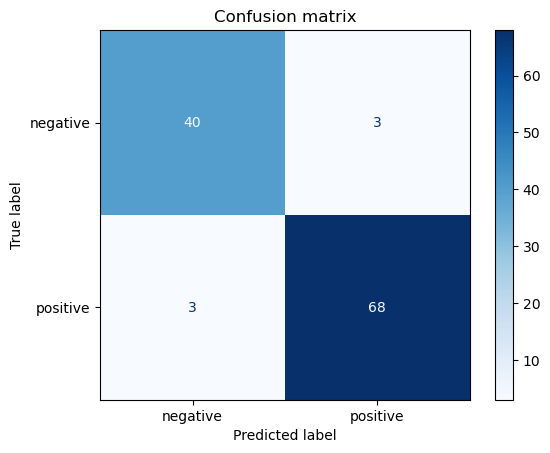

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_true = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(max_depth=5)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)


from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['negative', 'positive']
)
disp.plot(values_format='d', cmap='Blues')
disp.ax_.set_title('Confusion matrix')

The following metrics are frequently used:
1. **Accuracy** is the fraction of correctly classified samples:
$$
\text{Acc} = \frac{TP+TN}{TP+FN+FP+TN}.
$$

2. **Precision** is the fraction of predicted positives that are actually positive:
$$
\text{Pre} = \frac{TP}{TP+FP}.
$$

3. **Recall**, also called *sensitivity* or *true positive rate*, is the fraction of positive samples that are correctly detected:
$$
\text{Rec} = \frac{TP}{TP+FN}.
$$

4. The **F$_1$-score** is the harmonic mean of precision and recall:
$$
F_1 = 2\,\frac{Pre\,Rec}{Pre+Rec}.
$$
Scikit-learn provides functions for computing these metrics:

In [7]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

acc = accuracy_score(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)
pre = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", round(100*acc, 2))
print("Balanced accuracy:", round(bacc, 2))
print("Precision:", round(pre, 2))
print("Recall:", round(rec, 2))
print("F1-score:", round(f1, 2))

Accuracy: 94.74
Balanced accuracy: 0.94
Precision: 0.96
Recall: 0.96
F1-score: 0.96


Another useful measure for binary classification is the **Matthews correlation coefficient** (MCC), which combines all four entries of the confusion matrix:
$$
\mathrm{MCC} = \frac{TP \times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}.
$$
The MCC ranges from $-1$ to $1$. A value of $1$ indicates perfect classification, $0$ corresponds to performance with no overall correlation between predictions and true labels, and $-1$ indicates complete disagreement. Unlike accuracy, the MCC remains informative when the classes are highly unbalanced because it takes into account true and false predictions for both classes. It can therefore provide a useful single-number summary when the class distribution is uneven.

In [8]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_true, y_pred)
print("MCC:", round(mcc, 2))

MCC: 0.89


#### Multiclass confusion matrix

The confusion matrix can also be used for classification problems involving more than *two* classes. For a problem with $K$ classes, it is represented by a $K \times K$ matrix $\mathbf{C}$, whose element $C_{ij}$ denotes the number of samples belonging to the true class $i$ that are predicted as class $j$:
$$
C_{ij} = \left\{ n:y_n=i,\ \widehat{y}_n=j \right\}.
$$
Here, the rows represent the true classes and the columns represent the predicted classes, although the opposite convention may occasionally be used.

For each class $k$, the multiclass problem can be interpreted as a binary **one-versus-rest** problem. The corresponding quantities are:
$$
\mathrm{TP}_k = C_{kk}, \qquad
\mathrm{FN}_k = \sum_{j\neq k} C_{kj}, \qquad
\mathrm{FP}_k = \sum_{i\neq k} C_{ik}, \qquad
\mathrm{TN}_k = \sum_{i\neq k}\sum_{j\neq k} C_{ij}.
$$
For *multiclass* problems, precision, recall, and F$_1$ can be computed for each class and then combined through the `average` argument:
- `micro` aggregates the contributions of all classes before computing the metric;
- `macro` computes the unweighted mean of the class-wise scores and therefore gives equal importance to every class;
- `weighted` computes a class-wise average weighted by the number of true samples in each class;
- `samples` computes the metric independently for each sample and is meaningful only for multilabel classification;
- `None` returns one score for each class.

For example:

In [9]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

X, y = load_wine(return_X_y=True)

X_train, X_test, y_train, y_true = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeRegressor(max_depth=10)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

pre_macro = precision_score(y_true, y_pred, average='macro')
rec_micro = recall_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
f1_per_class = f1_score(y_true, y_pred, average=None)

print("Macro precision:", round(pre_macro, 2))
print("Micro recall:", round(rec_micro, 2))
print("Weighted F1-score:", round(f1_weighted, 2))
print("Per-class F1-score:", f1_per_class)

Macro precision: 0.94
Micro recall: 0.92
Weighted F1-score: 0.91
Per-class F1-score: [0.96551724 0.93333333 0.76923077]


A complete summary of precision, recall, F$_1$, and support can be generated with `classification_report`:

In [10]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=['Class 1', 'Class 2', 'Class 3'],
    digits=3   # Set the numeric precision
))

              precision    recall  f1-score   support

     Class 1      0.933     1.000     0.966        14
     Class 2      0.875     1.000     0.933        14
     Class 3      1.000     0.625     0.769         8

    accuracy                          0.917        36
   macro avg      0.936     0.875     0.889        36
weighted avg      0.925     0.917     0.909        36



#### ROC curves and ROC AUC

The **receiver operating characteristic** (ROC) curve evaluates a binary scoring classifier over a range of decision thresholds. It plots the *true positive rate* (TPR) against the *false positive rate* (FPR), defined as:
$$
\text{TPR} = \frac{TP}{TP+FN} \qquad \text{and} \qquad \text{FPR} = \frac{FP}{FP+TN}.
$$
The curve and its thresholds can be computed as follows:

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_true = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(max_depth=5)

tree.fit(X_train, y_train)
#y_pred = tree.predict(X_test)
y_proba = tree.predict_proba(X_test)
y_score = y_proba[:,1]

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_score)

A convenient display can be created directly from the true labels and scores:

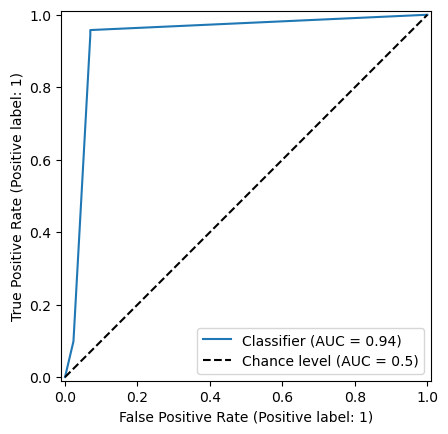

In [12]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_true, y_score,
    plot_chance_level=True
)

The area under the **ROC curve** (ROC AUC) summarizes the ranking performance in a single value. An AUC of $1$ represents perfect ranking, whereas an AUC of approximately $0.5$ corresponds to random ranking. A value below $0.5$ indicates that the ranking is systematically reversed.

If the ROC points have already been computed, their area can be evaluated with:

In [13]:
from sklearn.metrics import auc

roc_auc = auc(fpr, tpr)

More directly:

In [14]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_true, y_score)

print("AUC:", roc_auc)

AUC: 0.9359646249590566


For multiclass classification, ROC curves are commonly computed using a **one-vs-rest** (OvR) or **one-vs-one** (OvO) strategy, producing a separate curve and AUC value for each class or class pair.

#### Precision-recall curves

Precision and recall are often characterized by a trade-off controlled by the classifier decision threshold. Lowering the threshold generally increases recall, since more positive samples are detected, but it may reduce precision by producing more false positives. Conversely, raising the threshold usually improves precision while increasing the number of false negatives and therefore reducing recall.

A **precision-recall** (PR) curve plots precision against recall as the decision threshold varies. It is particularly informative when the positive class is rare and identifying it is the main objective.

Precision-recall pairs can be computed with:

In [15]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, y_score)

The curve can be displayed directly:

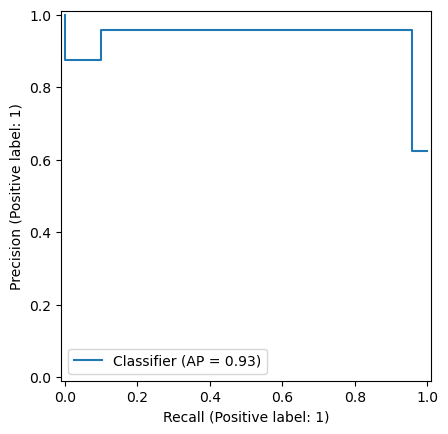

In [16]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_true, y_score)

A common scalar summary is the **average precision** (AP), which computes a recall-weighted average of the precision values:
$$
AP = \sum_n \left(R_n-R_{n-1}\right)P_n,
$$
where $P_n$ and $R_n$ are the precision and recall at the $n$-th threshold:

In [17]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_true, y_score)

print("Average precision:", ap)

Average precision: 0.9349259008461444


## Cross-validation <a id="CV"></a>

The holdout estimate may vary considerably with the selected validation samples. In **$k$-fold cross-validation**, the development dataset is partitioned into $k$ non-overlapping subsets called *folds*. The procedure consists of the following steps:
1. select one fold as the validation fold and use the remaining $k-1$ folds for training;
2. fit the complete learning procedure on the training folds and evaluate it on the validation fold;
3. repeat the procedure $k$ times, so that every fold is used once for validation;
4. summarize the $k$ validation scores, commonly through their mean and standard deviation.

If $s_j$ is the score obtained in fold $j$, the cross-validation mean and standard deviation are:
$$
\overline{s} = \frac{1}{k} \sum_{j=1}^{k}s_j \qquad \text{and} \qquad \sigma_s = \sqrt{\frac{1}{k} \sum_{j=1}^{k} \left(s_j-\overline{s}\right)^2}.
$$
Values of $k=5$ or $k=10$ are common compromises between computational cost and estimation reliability.

The **leave-one-out** method (LOO) is the limiting case $k=N$, where each validation fold contains one sample. LOO uses almost all observations for every fit, but it requires $N$ training runs and can produce a high-variance estimate. Therefore, it is not automatically the best choice for a small dataset.

Several cross-validation variants are useful in practice:
- **Stratified $k$-fold**** approximately preserves the class proportions in every fold and is usually preferred for classification;
- **Repeated $k$-fold**** repeats cross-validation with different randomized partitions, providing a more stable empirical distribution of the scores;
- **Group-based cross-validation**** keeps all samples belonging to the same subject, patient, device, or other group in the same fold;
- **Time-series cross-validation**** respects temporal order and avoids training on observations that occur after the validation samples.

> The cross-validation splitter must reflect the data-generation process. Ordinary random folds can produce overly optimistic results when samples from the same subject or recording appear in both training and validation folds, or when future observations are used to predict the past.

The following self-contained example creates a classification pipeline and reserves an independent test set. Cross-validation is performed only on the training set:

In [18]:
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

A manual stratified cross-validation loop can be implemented with `StratifiedKFold`:

In [19]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
for fold, (train_idx, val_idx) in enumerate(
        cv.split(X_train, y_train), start=1):

    pipe.fit(X_train[train_idx], y_train[train_idx])
    score = pipe.score(X_train[val_idx], y_train[val_idx])
    scores.append(score)

    distribution = np.bincount(y_train[val_idx])
    print(
        f'Fold {fold}: class distribution={distribution}, '
        f'accuracy={score:.3f}'
    )

print(
    f'CV accuracy: {np.mean(scores):.3f} '
    f'+/- {np.std(scores):.3f}'
)

Fold 1: class distribution=[34 57], accuracy=0.967
Fold 2: class distribution=[34 57], accuracy=0.989
Fold 3: class distribution=[34 57], accuracy=0.978
Fold 4: class distribution=[34 57], accuracy=0.989
Fold 5: class distribution=[34 57], accuracy=0.967
CV accuracy: 0.978 +/- 0.010


The same evaluation can be performed more compactly with the function `cross_val_score`:

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    estimator=pipe,
    X=X_train,
    y=y_train,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

print(f'Fold scores: {scores}')
print(
    f'CV accuracy: {scores.mean():.3f} '
    f'+/- {scores.std():.3f}'
)

Fold scores: [0.96703297 0.98901099 0.97802198 0.98901099 0.96703297]
CV accuracy: 0.978 +/- 0.010


When several metrics are required, `cross_validate` can evaluate them in one call:

In [21]:
from sklearn.model_selection import cross_validate

results = cross_validate(
    pipe,
    X_train,
    y_train,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    cv=cv,
    n_jobs=-1
)

print(results['test_accuracy'].mean())
print(results['test_f1'].mean())

0.9780219780219781
0.9825442464894886


Repeated stratified cross-validation can be obtained with the function `RepeatedStratifiedKFold`:

In [22]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

scores = cross_val_score(
    pipe,
    X_train,
    y_train,
    scoring='accuracy',
    cv=repeated_cv,
    n_jobs=-1
)

print(f'Number of scores: {scores.size}')
print(
    f'Repeated CV accuracy: {scores.mean():.3f} '
    f'+/- {scores.std():.3f}'
)

Number of scores: 15
Repeated CV accuracy: 0.973 +/- 0.010


For regression, ordinary `KFold` is generally used instead of stratified splitting:

In [23]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_reg, y_reg = load_diabetes(return_X_y=True)

regressor = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

neg_rmse = cross_val_score(
    regressor,
    X_reg,
    y_reg,
    scoring='neg_root_mean_squared_error',
    cv=cv_reg
)

rmse = -neg_rmse
print(f'CV RMSE: {rmse.mean():.3f} +/- {rmse.std():.3f}')

CV RMSE: 54.827 +/- 2.564


## Imbalanced learning and probability calibration <a id="Imbalanced"></a>

A classification dataset is said to be **imbalanced** when some classes contain substantially fewer samples than others. In this case, accuracy may provide a misleading evaluation. For example, a classifier that always predicts the majority class obtains an accuracy of 95% on a dataset in which only 5% of the samples belong to the minority class, although it never detects the latter.

For imbalanced problems, the evaluation should therefore include metrics such as precision, recall, the $F_1$-score, balanced accuracy, and the area under the precision-recall curve. The appropriate metric depends on the application. High recall is important when missing a positive sample is costly, whereas high precision is preferred when false alarms must be limited.

Many classifiers produce a score or an estimated probability in addition to a class label. A classifier is said to be ***well calibrated*** when its predicted probabilities agree with observed frequencies. For example, among samples assigned a probability close to $0.8$, approximately 80% should belong to the positive class.

Calibration can be assessed using a **calibration curve**, also called a *reliability diagram*, which compares the average predicted probability with the observed positive-class frequency in different probability intervals. A perfectly calibrated classifier follows the diagonal line. A numerical measure of calibration is the **Brier score**:
$$
\operatorname{BS} = \frac{1}{N} \sum_{n=1}^{N} \left(\widehat{p}_n-y_n\right)^2,
$$
where $y_n \in \{0, 1\}$ and $\widehat{p}_n$ is the predicted probability of the positive class. Lower values indicate better probabilistic predictions.

The following example trains a class-weighted logistic-regression model and calibrates its probabilities using cross-validation:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       916
           1       0.89      0.37      0.52        84

    accuracy                           0.94      1000
   macro avg       0.92      0.68      0.75      1000
weighted avg       0.94      0.94      0.93      1000

Average precision: 0.6051681856066404
Brier score: 0.04984287716072916


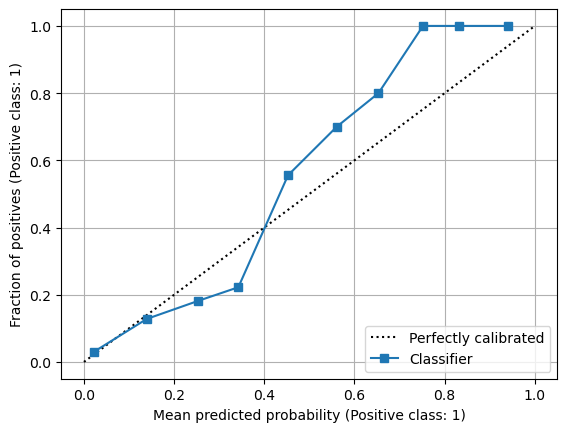

In [24]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import average_precision_score, brier_score_loss, classification_report
import matplotlib.pyplot as plt

X, y = make_classification(
    n_samples=4000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    weights=[0.92, 0.08],
    flip_y=0.01,
    random_state=1
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=1
)

base_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=1
)

model = CalibratedClassifierCV(
    estimator=base_model,
    method='sigmoid',
    cv=5
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print('Average precision:', average_precision_score(y_test, y_prob))
print('Brier score:', brier_score_loss(y_test, y_prob))

CalibrationDisplay.from_predictions(y_test, y_prob, n_bins=10)
plt.grid()
plt.show()

## Model interpretation <a id="Interpretation"></a>

Good predictive performance does not by itself explain how a model reaches its decisions. **Model interpretation** aims to identify which input variables influence the predictions and how their values affect the output. Interpretability can be *global*, describing the overall behavior of the model, or *local*, explaining an individual prediction.

A general model-independent technique is **permutation importance**. After evaluating the fitted model on a validation or test set, one feature is randomly permuted while all other features remain unchanged. The reduction in predictive performance measures the model's dependence on that feature. Repeating the permutation provides a more stable estimate:
$$
I_j = S(\mathcal{D}) - \frac{1}{R} \sum_{r=1}^{R} S\!\left(\mathcal{D}_{j}^{(r)}\right),
$$
where $S$ is the selected score and $\mathcal{D}_{j}^{(r)}$ denotes the dataset obtained by permuting feature $j$ in repetition $r$. A large value of $I_j$ indicates that the feature is important for the fitted model.

The following example computes permutation importance for a decision tree classifier:

In [25]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=1
)

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring='balanced_accuracy',
    n_repeats=20,
    random_state=1,
    n_jobs=-1
)

order = np.argsort(result.importances_mean)[::-1]

for index in order[:10]:
    print(
    f'{data.feature_names[index]:30s} '
    f'{result.importances_mean[index]:.4f} '
    f'+/- {result.importances_std[index]:.4f}'
    )

worst concavity                0.1676 +/- 0.0319
worst perimeter                0.1585 +/- 0.0243
mean area                      0.1352 +/- 0.0155
worst area                     0.1157 +/- 0.0201
area error                     0.0393 +/- 0.0150
worst concave points           0.0203 +/- 0.0185
mean texture                   0.0135 +/- 0.0093
mean perimeter                 0.0000 +/- 0.0000
texture error                  0.0000 +/- 0.0000
mean smoothness                0.0000 +/- 0.0000


## Monitoring and change detection <a id="Change"></a>

The evaluation of a machine-learning model does not end when the model is deployed. The statistical properties of the data encountered during operation may change with time, causing the performance measured during development to become no longer representative. This phenomenon is generally referred to as **distribution shift**. Changes may affect the input distribution $p(\mathbf{x})$, the target distribution $p(y)$, or the relationship between inputs and outputs $p(y\mid\mathbf{x})$, the latter being commonly called **concept drift**. For this reason, deployed models should be monitored using suitable performance and data-quality indicators.

A **change detector** monitors a statistic derived from incoming data or prediction errors and compares its behavior with a reference condition. Instead of reacting to isolated fluctuations, sequential detectors accumulate evidence of persistent deviations and signal a change when this evidence exceeds a predefined threshold. The threshold therefore controls the trade-off between false alarms and detection delay.

A classical sequential change-detection technique is the **cumulative sum** (CUSUM) method. Assume that a scalar quantity $z_n$ is monitored during operation. This quantity may represent, for example, the prediction error, the loss, a feature value, or another statistic characterizing the incoming data.

Let $\mu_0$ denote its expected value under normal operating conditions. A one-sided CUSUM detector for an increase in the monitored quantity can be written as:
$$
g_n = \max\left\{0,\,g_{n-1}+z_n-\mu_0-\nu\right\}, \qquad g_0=0,
$$
where $\nu>0$ is a small tolerance, sometimes called the *reference* or *allowance* parameter. A change is declared when $g_n > h$, where $h>0$ is the detection threshold.

The following example generates a sequence whose mean changes from $0$ to $1$ after sample $500$. A one-sided CUSUM detector is used to identify the increase.

Actual change: 500
Detected change: 507


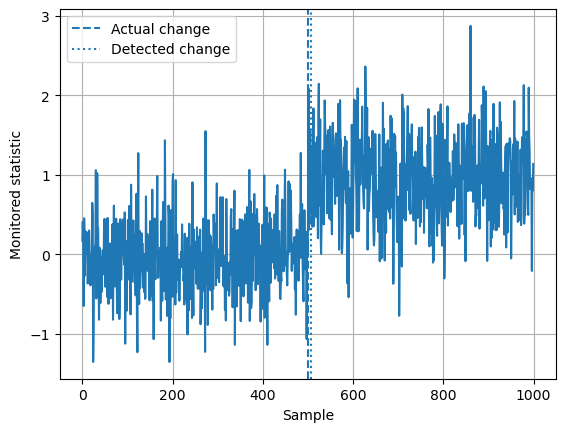

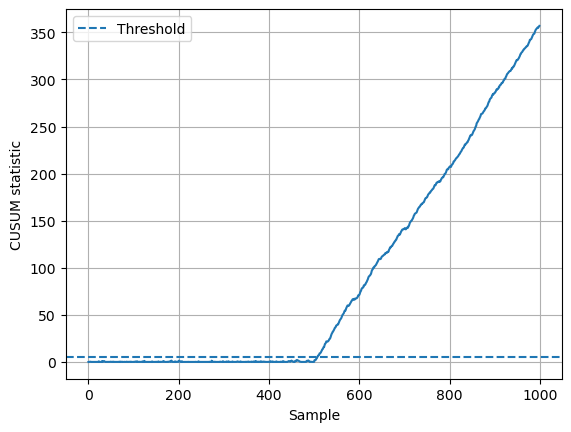

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a sequence with a change in the mean
rng = np.random.default_rng(1)

N = 1000
change_point = 500

z = rng.normal(0.0, 0.5, N)
z[change_point:] += 1.0

# CUSUM parameters
mu0 = 0.0       # reference mean
nu = 0.25       # tolerance
h = 5.0         # detection threshold

g = np.zeros(N)
detected_change = None

for n in range(1, N):
    g[n] = max(0.0, g[n-1] + z[n] - mu0 - nu)
    if g[n] > h and detected_change is None:
        detected_change = n

print("Actual change:", change_point)
print("Detected change:", detected_change)

# Plot monitored data
plt.figure()
plt.plot(z)
plt.grid()
plt.axvline(change_point, linestyle='--', label='Actual change')
plt.axvline(detected_change, linestyle=':', label='Detected change')
plt.xlabel('Sample')
plt.ylabel('Monitored statistic')
plt.legend()
plt.show()

# Plot CUSUM statistic
plt.figure()
plt.plot(g)
plt.grid()
plt.axhline(h, linestyle='--', label='Threshold')
plt.xlabel('Sample')
plt.ylabel('CUSUM statistic')
plt.legend()
plt.show()

An alternative sequential change-detection method is the **Page-Hinkley test**. Like CUSUM, it detects persistent deviations in a monitored statistic, but instead of relying on a fixed reference mean, it compares the incoming observations with a running estimate of their average behavior. Let
$$
\bar z_n = \bar z_{n-1} + \frac{z_n-\bar z_{n-1}}{n}
$$
denote the running mean of the monitored sequence. The cumulative deviation is updated as:
$$
m_n = m_{n-1} + z_n-\bar z_n-\delta,
$$
where $\delta>0$ is a small tolerance parameter. The minimum value reached by the cumulative statistic is stored as:
$$
M_n = \min\left(M_{n-1},m_n\right).
$$
A change is declared when $m_n-M_n>\lambda$, where $\lambda>0$ is the detection threshold.

Actual change: 500
Detected change: 506


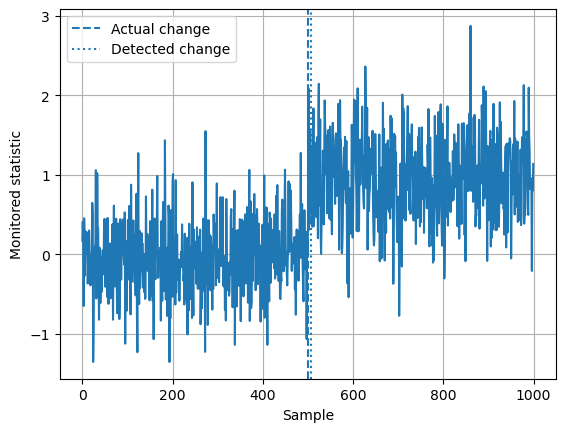

In [27]:
import numpy as np

def page_hinkley(z, delta=0.01, threshold=10.0):
    mean = 0.0
    cumulative = 0.0
    minimum = 0.0

    for n, value in enumerate(z, start=1):

        # Running mean
        mean += (value - mean) / n

        # Cumulative deviation
        cumulative += value - mean - delta

        # Historical minimum
        minimum = min(minimum, cumulative)

        # Change detection
        if cumulative - minimum > threshold:
            return n - 1

    return None


# Generate a sequence with a change in the mean
rng = np.random.default_rng(1)

N = 1000
change_point = 500

z = rng.normal(0.0, 0.5, N)
z[change_point:] += 1.0


detected_change = page_hinkley(z, threshold=20)


if detected_change is not None:
    print("Actual change:", change_point)
    print("Detected change:", detected_change)
    
    # Plot monitored data
    plt.figure()
    plt.plot(z)
    plt.grid()
    plt.axvline(change_point, linestyle='--', label='Actual change')
    plt.axvline(detected_change, linestyle=':', label='Detected change')
    plt.xlabel('Sample')
    plt.ylabel('Monitored statistic')
    plt.legend()
    plt.show()
else:
    print("No change detection detected")

## Hyperparameter optimization <a id="Hype_opt"></a>

Model parameters are learned from the training data. *Hyperparameters*, instead, control the learning algorithm or the model structure and are specified before fitting. Examples include `C`, `kernel`, and `gamma` for an SVM, the maximum depth of a decision tree, and the regularization strength of a linear model.

Scikit-learn provides several search strategies, including:
1. **exhaustive grid search**, which evaluates every combination in a finite grid;
2. **randomized search**, which evaluates a fixed number of configurations sampled from specified distributions;
3. **successive-halving methods**, which progressively allocate more resources to the most promising candidates.


### Grid search <a id="Grid_search"></a>

Grid search requires a finite set of candidate values for every tuned hyperparameter. Suppose, for example, that an RBF SVM is evaluated for:
$$
C \in \left\{10^{-3},10^{-2},\ldots,10^3\right\} \quad \text{and} \quad \gamma \in \left\{10^{-4},10^{-3},\ldots,10^1\right\}.
$$
The Cartesian product of these sets defines the candidate configurations. Because parameters such as $C$ and $\gamma$ may vary over several orders of magnitude, logarithmically spaced values are usually more appropriate than a linear grid.

Parameters of nested estimators are addressed with the syntax `step__parameter`. For a pipeline created with the function `make_pipeline(StandardScaler(), SVC())`, the automatically generated step name is `svc`, so the regularization parameter is written as `svc__C`.

The following example tunes a linear and an RBF SVM:

In [28]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe_svc = make_pipeline(StandardScaler(), SVC())

c_values = np.logspace(-3, 3, 7)
gamma_values = np.logspace(-4, 1, 6)

param_grid = [
    {'svc__kernel': ['linear'], 'svc__C': c_values},
    {'svc__kernel': ['rbf'], 'svc__C': c_values, 'svc__gamma': gamma_values}
]

grid_search = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    refit=True,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f'Best CV score: {grid_search.best_score_:.3f}')
print(f'Best parameters: {grid_search.best_params_}')

test_score = grid_search.score(X_test, y_test)
print(f'Test accuracy: {test_score:.3f}')

Best CV score: 0.978
Best parameters: {'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Test accuracy: 0.982


With `refit=True`, the best configuration is automatically refitted on the complete training set and is available through `best_estimator_`. The test score should be computed only after the search space and evaluation procedure have been finalized.

### Nested grid search <a id="Nested_grid_search"></a>

A nested cross-validation estimate can be simply obtained by passing a `GridSearchCV` object to `cross_val_score`:

In [29]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

nested_search = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=inner_cv,
    n_jobs=-1
)

nested_scores = cross_val_score(
    nested_search,
    X_train,
    y_train,
    scoring='accuracy',
    cv=outer_cv,
    n_jobs=-1
)

print(
    f'Nested CV accuracy: {nested_scores.mean():.3f} '
    f'+/- {nested_scores.std():.3f}'
)

Nested CV accuracy: 0.967 +/- 0.010


### Randomized search <a id="Randomized_search"></a>

Grid search becomes expensive when many hyperparameters or candidate values are considered. Randomized search samples only a predefined number of configurations. Its computational budget is controlled directly by `n_iter`, independently of the size of the parameter space.

For positive scale parameters that may span several orders of magnitude, a log-uniform distribution is often suitable:

In [30]:
from scipy.stats import loguniform

from sklearn.model_selection import RandomizedSearchCV

param_distributions = [
    {'svc__kernel': ['linear'], 'svc__C': loguniform(1e-3, 1e3)},
    {
        'svc__kernel': ['rbf'],
        'svc__C': loguniform(1e-3, 1e3),
        'svc__gamma': loguniform(1e-4, 1e1)
    }
]

random_search = RandomizedSearchCV(
    estimator=pipe_svc,
    param_distributions=param_distributions,
    n_iter=40,
    scoring='accuracy',
    cv=cv,
    refit=True,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f'Best CV score: {random_search.best_score_:.3f}')
print(f'Best parameters: {random_search.best_params_}')
print(
    f'Test accuracy: '
    f'{random_search.score(X_test, y_test):.3f}'
)

Best CV score: 0.976
Best parameters: {'svc__C': 12.746711578215052, 'svc__gamma': 0.015876781526923997, 'svc__kernel': 'rbf'}
Test accuracy: 0.982


### Successive halving <a id="Halving"></a>

Scikit-learn also provides the two functions `HalvingGridSearchCV` and `HalvingRandomSearchCV`. **Successive halving** initially evaluates many candidates using a small resource budget. At each iteration, poorly performing candidates are discarded, while the remaining candidates receive progressively more resources. By default, the resource is the number of training samples, although an iterative-estimator parameter such as `n_estimators` may also be used.

The `factor` parameter controls both the increase in resources and the reduction in the number of candidates between iterations. These estimators are experimental and must be explicitly enabled before they are imported:

In [31]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import HalvingRandomSearchCV

The `HalvingGridSearchCV` is applied as:

In [32]:
c_values = np.logspace(-3, 3, 7)
gamma_values = np.logspace(-4, 1, 6)

param_grid = [
    {'svc__kernel': ['linear'], 'svc__C': c_values},
    {'svc__kernel': ['rbf'], 'svc__C': c_values, 'svc__gamma': gamma_values}
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

halv_search = HalvingGridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    refit=True,
    random_state=42,
    n_jobs=-1
)

halv_search.fit(X_train, y_train)

print(f'Best CV score: {halv_search.best_score_:.3f}')
print(f'Best parameters: {halv_search.best_params_}')
print(
    f'Test accuracy: '
    f'{halv_search.score(X_test, y_test):.3f}'
)

Best CV score: 0.961
Best parameters: {'svc__C': 1.0, 'svc__kernel': 'linear'}
Test accuracy: 0.956


The `HalvingRandomSearchCV` is applied as:

In [33]:
param_distributions = [
    {'svc__kernel': ['linear'], 'svc__C': loguniform(1e-3, 1e3)},
    {
        'svc__kernel': ['rbf'],
        'svc__C': loguniform(1e-3, 1e3),
        'svc__gamma': loguniform(1e-4, 1e1)
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

halv_search = HalvingRandomSearchCV(
    estimator=pipe_svc,
    param_distributions=param_distributions,
    scoring='accuracy',
    cv=cv,
    refit=True,
    random_state=42,
    n_jobs=-1
)

halv_search.fit(X_train, y_train)

print(f'Best CV score: {halv_search.best_score_:.3f}')
print(f'Best parameters: {halv_search.best_params_}')
print(
    f'Test accuracy: '
    f'{halv_search.score(X_test, y_test):.3f}'
)

Best CV score: 0.956
Best parameters: {'svc__C': 3.8115440886530614, 'svc__kernel': 'linear'}
Test accuracy: 0.974
